# Dependency package

In [114]:
import os
import time
import numpy as np

import mne
from mne.channels import make_standard_montage
# from mne.decoding import CSP

import sklearn
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import KFold , train_test_split , GridSearchCV
from sklearn.ensemble import VotingClassifier

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

import scipy
from scipy import stats
from scipy.io import loadmat
from scipy.signal import welch

from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

import pyriemann
from pyriemann.clustering import Kmeans as pyKmeans

print(f"numpy version: {np.__version__}")
print(f"mne version: {mne.__version__}")
print(f"sklearn version: {sklearn.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"pyriemann version: {pyriemann.__version__}")
start_time = time.time()

numpy version: 2.2.6
mne version: 1.10.1
sklearn version: 1.7.2
scipy version: 1.15.3
pyriemann version: 0.10


# Dataset Setting

In [115]:
# Select dataset
# 0: BCICIV_2a
# 1: BCICIV_2b
# 2: BCICIV_1
Dataset_Selection = 2


match Dataset_Selection:
    case 0:
        gdf_dirPath = f'../../dataset/BCICIV_2a_gdf/' # GDF read dir path
        mat_dirPath = None
        participants = [] # EEG-MI 受試者
        participantsNum = 9 # EEG-MI 受試者人數
        for i in range(1,participantsNum+1,1):
            participants = participants + [f'A0{i}T']  # bci4_2A
        saveResultPath = './result_bci4_2a/' # 結果儲存資料夾
        target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
        # BCI4 2A 資料集電擊轉換成標準10-20系統
        channel_rename_map = {
            'EEG-Fz' : 'Fz'  ,
            'EEG-0'  : 'FC3' ,
            'EEG-1'  : 'FC1' ,
            'EEG-2'  : 'FCz' ,
            'EEG-3'  : 'FC2' ,
            'EEG-4'  : 'FC4' ,
            'EEG-5'  : 'C5'  ,
            'EEG-C3' : 'C3'  ,
            'EEG-6'  : 'C1'  ,
            'EEG-Cz' : 'Cz'  ,
            'EEG-7'  : 'C2'  ,
            'EEG-C4' : 'C4'  ,
            'EEG-8'  : 'C6'  ,
            'EEG-9'  : 'CP3' ,
            'EEG-10' : 'CP1' ,
            'EEG-11' : 'CPz' ,
            'EEG-12' : 'CP2' ,
            'EEG-13' : 'CP4' ,
            'EEG-14' : 'P1'  ,
            'EEG-Pz' : 'Pz'  ,
            'EEG-15' : 'P2'  ,
            'EEG-16' : 'POz' ,
            'EOG-left'   : 'EOG-left',
            'EOG-central': 'EOG-central',
            'EOG-right'  : 'EOG-right'
        }
        channel_types = {
            'EEG-Fz' : 'eeg',
            'EEG-0'  : 'eeg',
            'EEG-1'  : 'eeg',
            'EEG-2'  : 'eeg',
            'EEG-3'  : 'eeg',
            'EEG-4'  : 'eeg',
            'EEG-5'  : 'eeg',
            'EEG-C3' : 'eeg',
            'EEG-6'  : 'eeg',
            'EEG-Cz' : 'eeg',
            'EEG-7'  : 'eeg',
            'EEG-C4' : 'eeg',
            'EEG-8'  : 'eeg',
            'EEG-9'  : 'eeg',
            'EEG-10' : 'eeg',
            'EEG-11' : 'eeg',
            'EEG-12' : 'eeg',
            'EEG-13' : 'eeg',
            'EEG-14' : 'eeg',
            'EEG-Pz' : 'eeg',
            'EEG-15' : 'eeg',
            'EEG-16' : 'eeg',
            'EOG-left'   : 'eog',
            'EOG-central': 'eog',
            'EOG-right'  : 'eog'
        }
        downsamplingFreq = None
    case 1:
        gdf_dirPath = f'../../dataset/BCICIV_2b_gdf/'
        mat_dirPath = None
        participants = []
        participantsNum = 9
        participantsId = ['B0103T','B0203T','B0303T','B0403T','B0503T','B0603T','B0703T','B0803T','B0303T']
        filenamePrefix = ''
        filenamePostfix = '.gdf'
        for i in participantsId:
            participants = participants + [i]  # bci4_2B
        saveResultPath = './result_bci4_2b/'
        target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
        # BCI4 2B 資料集電擊轉換成標準10-20系統
        channel_rename_map = {
            'EEG:C3' : 'C3'  ,
            'EEG:Cz' : 'Cz'  ,
            'EEG:C4' : 'C4'  ,
            'EOG:ch01':'EOG:ch01',
            'EOG:ch02':'EOG:ch02',
            'EOG:ch03':'EOG:ch03'
        }
        channel_types = {
            'EEG:C3'   : 'eeg',
            'EEG:Cz'   : 'eeg',
            'EEG:C4'   : 'eeg',
            'EOG:ch01' : 'eog',
            'EOG:ch02' : 'eog',
            'EOG:ch03' : 'eog'
        }
        downsamplingFreq = None
    case 2:
        gdf_dirPath = None
        mat_dirPath = f'../../dataset/BCICIV_1calib_1000Hz_mat/'
        participants = []
        participantsNum = 3
        participantsId = ['ds1b','ds1c','ds1g']
        filenamePrefix = 'BCICIV_calib_'
        filenamePostfix = '_1000Hz.mat'
        for i in participantsId:
            participants = participants + [i]  # bci4_1
        saveResultPath = './result_bci4_1/'
        target_keys = ['Left', 'Right'] # 任務
        # BCI4 2B 資料集電擊轉換成標準10-20系統
        channel_rename_map = None
        channel_types = None
        downsamplingFreq = 250

try:
    os.mkdir(saveResultPath) # 創建結果儲存資料夾
    os.mkdir(saveResultPath +'./confuseMatrix/') # 創建結果儲存資料夾
except:
    print("file exist")
    pass

file exist


# Pre-Processing Setting

In [116]:
# band pass filter
fs = 250
lowcut = 8
highcut = 30
filter_order = 8
filter_type = 'butter' # Butterworth
iir_params = dict(order=filter_order, ftype=filter_type)

# 擷取實驗時間，0秒是cued開始
# C: number of channels
# P: number of temporal points
# N: number of trials
# (tmax-tmin)*250+1=500
# tmax = (P-1)/fs+tmin
time_interval = 3.5
P = time_interval*fs
tmin = 0.5
tmax = (P-1)/fs+tmin
print(f"Time from {tmin} s to {tmax} s, sample point: {P}")

# CSP M值
M = 3

Time from 0.5 s to 3.996 s, sample point: 875.0


# Data Segmentation

In [117]:
montage = make_standard_montage('standard_1020')
if channel_rename_map:
    eeg_only_channels = [
        name
        for name in channel_rename_map.values()
        if not name.startswith('EOG')
    ]

## Create Epoch training data and testing data
epochs = {}
for subject in participants:
    if gdf_dirPath:
        gdf_filepath = gdf_dirPath + f'./{subject}.gdf'
        try:
            raw = mne.io.read_raw_gdf(gdf_filepath, preload=True, verbose="ERROR")
        except Exception as e:
            print(f"讀取 GDF 檔案時發生錯誤: {e}")
            raise
    elif mat_dirPath:
        try:
            mat_filepath = mat_dirPath + f'./{filenamePrefix}{subject}{filenamePostfix}'
            mat_data = loadmat(mat_filepath, struct_as_record=False, squeeze_me=True)
            eeg_data = mat_data['cnt']     # 這是訊號矩陣 (Time x Channels)
            sfreq = mat_data['nfo'].fs     # 採樣率
            ch_names = mat_data['nfo'].clab # 通道名稱
            classes = mat_data['nfo'].classes
            events_sample = mat_data['mrk'].pos - 1
            events_id = np.where(mat_data['mrk'].y == -1, 1, 2)

            info = mne.create_info(ch_names=list(ch_names), sfreq=sfreq, ch_types='eeg', verbose='Error')
            raw = mne.io.RawArray(eeg_data.T * 1e-6, info, verbose='Error')

            events = np.column_stack((
                events_sample,
                np.zeros_like(events_sample, dtype=int),
                events_id.astype(int)
            ))
            mapping = {1: 'Left', 2: 'Right'}
            annot = mne.annotations_from_events(
                events=events,
                sfreq=raw.info['sfreq'],
                event_desc=mapping
            )
            raw.set_annotations(annot)
        except Exception as e:
            print(f"讀取 GDF 檔案時發生錯誤: {e}")
            raise

    ## Raw setting
    if channel_types:
        raw.set_channel_types(channel_types, verbose="ERROR") # 設定電擊種類是EEG還是EOG
    if channel_rename_map:
        raw.rename_channels(channel_rename_map, verbose="ERROR") # 重新命名電擊名稱符合10-20系統
    if downsamplingFreq:
        raw.resample(sfreq=downsamplingFreq) # downsampling
    raw.set_eeg_reference([], verbose="ERROR") # 設定reference電擊
    raw.set_montage(montage, on_missing='ignore', verbose="ERROR") # 設定10-20系統

    ## Regression
    # model = mne.preprocessing.EOGRegression(picks='eeg', picks_artifact='eog')
    # model.fit(raw)
    # raw = model.apply(raw)
    if channel_rename_map:
        raw.pick_channels(eeg_only_channels, verbose="ERROR") # Remove EOG data
    raw.filter( # Bandpass filter
        l_freq=lowcut,
        h_freq=highcut,
        method='iir',
        iir_params=iir_params,
        verbose="ERROR"
    )

    ## 選取事件做成epoch
    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    kept_event_ids = {
        key: value
        for key, value in event_id.items()
        if key in target_keys
    }
    events_of_interest = events[np.isin(events[:, 2], list(kept_event_ids.values()))]
    new_id_mapping = {old_id: i for i, old_id in enumerate(kept_event_ids.values())}
    kept_event_ids = {key: i for i, key in enumerate(kept_event_ids.keys())}
    for i in range(len(events_of_interest)):
        old_val = events_of_interest[i, 2]
        events_of_interest[i, 2] = new_id_mapping[old_val]

    baseline = None # 不做基線校正，或您可以定義 (-0.5, 0)
    epoch = mne.Epochs(
        raw,
        events_of_interest,
        event_id=kept_event_ids,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,        # 將數據載入內存
        proj=False,           # 暫時不應用投影
        verbose="ERROR"
    )
    epochs[subject] = epoch
    print(f"{subject} epoch create successful")

ds1b epoch create successful
ds1c epoch create successful
ds1g epoch create successful


# Data Shape Check

In [118]:
for subject in participants:
    X = epochs[subject].get_data()
    y = epochs[subject].events[:, 2]
    print(f"{subject} X: {X.shape}")
    print(f"{subject} y: {y.shape}")

ds1b X: (200, 59, 875)
ds1b y: (200,)
ds1c X: (200, 59, 875)
ds1c y: (200,)
ds1g X: (200, 59, 875)
ds1g y: (200,)


# Bypass

In [119]:
class Bypass(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        '''
        X: 原始EEG訊號(trials, channels, samples)
        '''
        feat = np.var(X, axis=2)
        feat = np.abs(np.log(feat + 1e-15))
        return feat

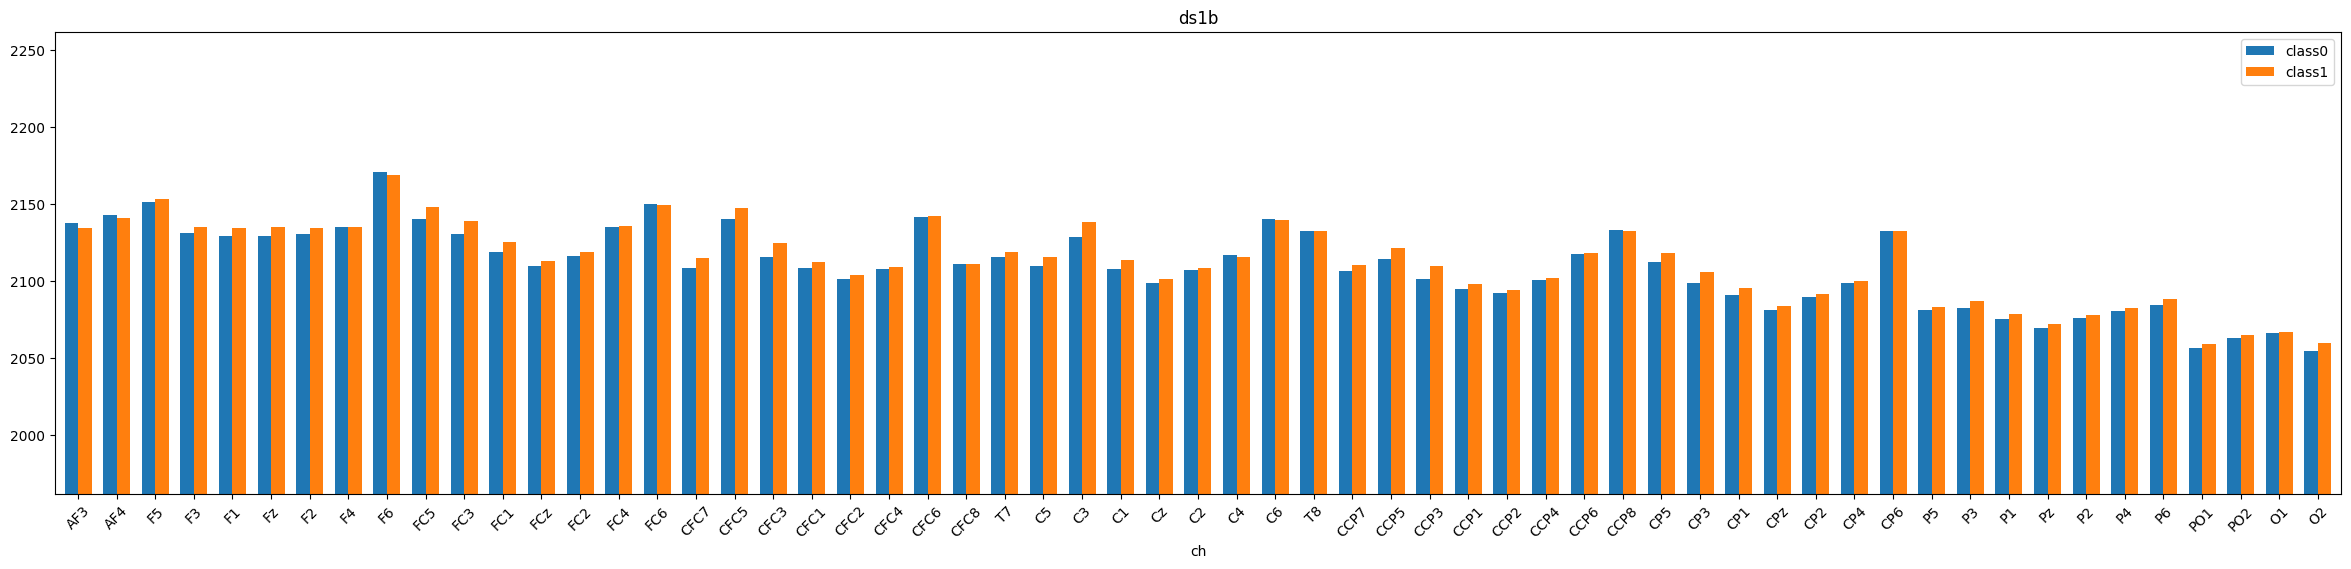

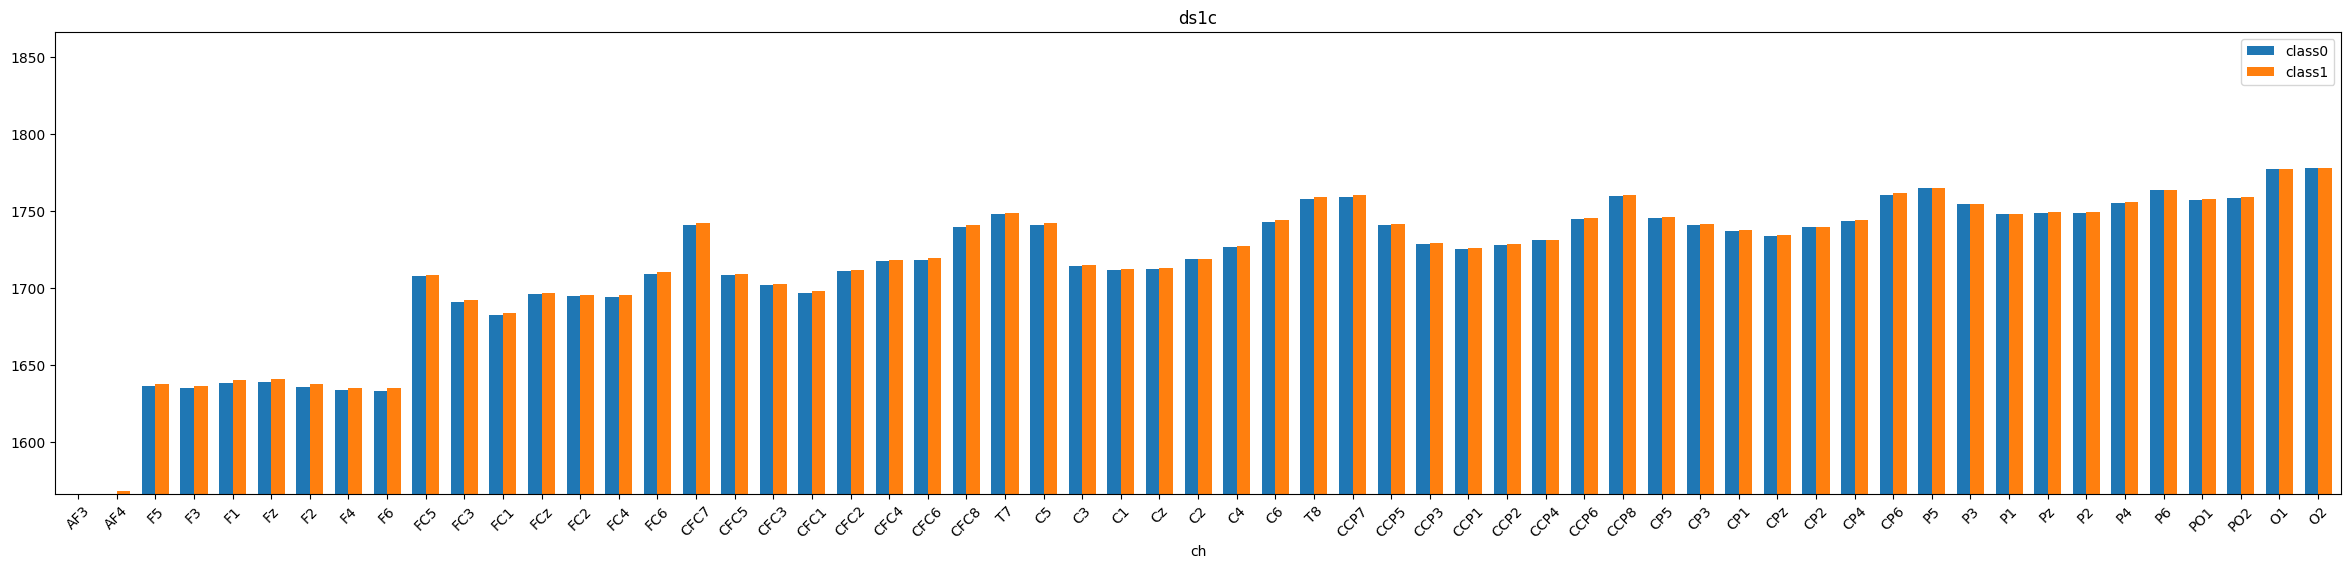

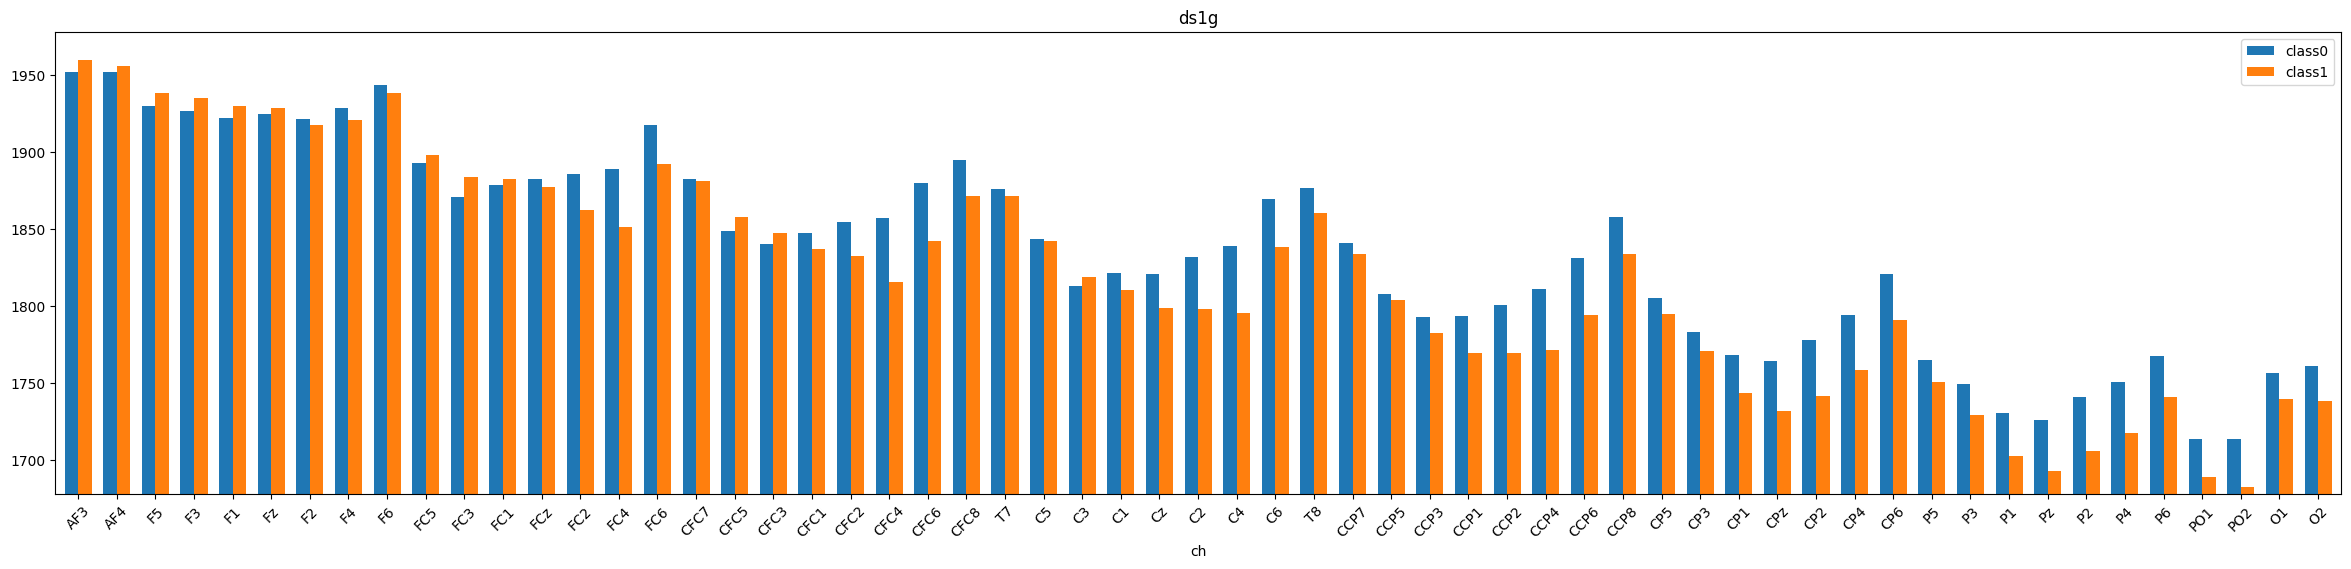

In [ ]:
FeatureExtractor = Bypass()
for subject in participants:
    X = epochs[subject].get_data()
    y = epochs[subject].events[:, 2]
    ch_list = epochs[subject].ch_names
    F = FeatureExtractor.transform(X)
    class0Feat = np.sum(F[np.where(y==0)], axis=0)
    class1Feat = np.sum(F[np.where(y==1)], axis=0)
    df = pd.DataFrame({
        'ch': ch_list,
        'class0' : class0Feat,
        'class1' : class1Feat,
    })
    df = df.set_index('ch')
    num_bars = len(df)
    calc_width = max(6, min(30, num_bars * 0.5))
    calc_height = 6
    rotation = 45 if num_bars > 15 else 0
    ax = df.plot.bar(figsize=(calc_width, calc_height), width=0.7, rot=rotation)
    center = df.values.mean()
    offset = 150
    ax.set_ylim(center - offset, center + offset)
    ax.set_title(f"{subject}")
    filename = saveResultPath +f"{subject}_power.png"
    plt.savefig(filename)
